# Лаб 2

(Помогите)

## Задание 1 🤯

Взять модели и датасеты с первой работы, добавить в обучение L1, L2, ElasticNet
и вывести по 4 графика на обучении, чтобы посмотреть ошибки/метрики (4 линии поразному подписанные на одном графике)

###Титаник

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [1]:
import pandas as pd

# Очищаем датасет

titanic = pd.read_csv('Titanic-Dataset.csv')
titanic.Sex = titanic.Sex.map({'female':0, 'male':1})
titanic.Embarked = titanic.Embarked.map({'S':0, 'C':1, 'Q':2,'nan':'NaN'})
titanic = titanic.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
mean_age_men=titanic[titanic['Sex']==1]['Age'].mean()
mean_age_women=titanic[titanic['Sex']==0]['Age'].mean()

titanic.loc[(titanic.Age.isnull()) & (titanic['Sex']==0),'Age']=mean_age_women
titanic.loc[(titanic.Age.isnull()) & (titanic['Sex']==1),'Age']=mean_age_men

titanic.dropna(inplace=True)

titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.000000,1,0,7.2500,0
1,1,1,0,38.000000,1,0,71.2833,1
2,1,3,0,26.000000,0,0,7.9250,0
3,1,1,0,35.000000,1,0,53.1000,0
4,0,3,1,35.000000,0,0,8.0500,0
...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,0
887,1,1,0,19.000000,0,0,30.0000,0
888,0,3,0,27.915709,1,2,23.4500,0
889,1,1,1,26.000000,0,0,30.0000,1


In [3]:
import numpy as np
from dataclasses import dataclass
import torch

@dataclass
class SeparateData:
  X_train: torch.Tensor
  y_train: torch.Tensor
  X_val: torch.Tensor
  y_val: torch.Tensor
  X_test: torch.Tensor
  y_test: torch.Tensor

class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X: torch.Tensor) -> None:
        X = X.clone().detach().to(torch.float32)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.mean = torch.mean(X, dim=0)
        self.std = torch.std(X, dim=0)

        self.std = torch.where(self.std == 0, torch.tensor(1.0), self.std)

    def transform(self, X: torch.Tensor) -> torch.Tensor:
        if self.mean is None or self.std is None:
            return X

        X = X.clone().detach().to(torch.float32)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return (X - self.mean) / self.std

    def fit_transform(self, X: torch.Tensor) -> torch.Tensor:
        self.fit(X)
        return self.transform(X)

class DataSeparator:
   def __init__(self, val_size: float = 0.2, test_size: float = 0.1,
                 shuffle: bool = True, seed: int = 42, device: torch.device = device):
        self.val_size = val_size
        self.test_size = test_size
        self.shuffle = shuffle
        self.seed = seed
        self.device = device

   def separate(self, X: torch.tensor, y: torch.tensor) -> SeparateData:
    n_samples = X.shape[0]
    indices = torch.arange(n_samples)

    if self.shuffle:
         torch.manual_seed(self.seed)
         indices = torch.randperm(n_samples)

    test_samples = int(n_samples * self.test_size)
    val_samples = int(n_samples * self.val_size)
    train_samples = n_samples - test_samples - val_samples

    train_indices = indices[:train_samples]
    val_indices = indices[train_samples: train_samples + val_samples]
    test_indices = indices[train_samples + val_samples:]

    X_train = torch.tensor(X[train_indices], dtype=torch.float32, device=self.device)
    y_train = torch.tensor(y[train_indices], dtype=torch.float32, device=self.device)
    X_val = torch.tensor(X[val_indices], dtype=torch.float32, device=self.device)
    y_val = torch.tensor(y[val_indices], dtype=torch.float32, device=self.device)
    X_test = torch.tensor(X[test_indices], dtype=torch.float32, device=self.device)
    y_test = torch.tensor(y[test_indices], dtype=torch.float32, device=self.device)

    return SeparateData(X_train, y_train, X_val, y_val, X_test, y_test)

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
import torch

@dataclass
class TrainingHistoryLogistic:
    losses: list[float]
    accuracies: list[float]
    f1_scores: list[float]
    val_losses: list[float]
    val_accuracies: list[float]
    val_f1_scores: list[float]
    weights_norm: list[float]


class LogisticRegression:
  def __init__(self, learning_rate: float = 0.01, n_iterations: int = 1000, regularization: str = None,
                 tolerance: float = 1e-6, fit_intercept: bool = True, verbose: bool = False, alpha: float = 0.01, l1_ratio: float = 0.5):
    self.learning_rate = learning_rate
    self.n_iterations = n_iterations
    self.tolerance = tolerance
    self.fit_intercept = fit_intercept
    self.verbose = verbose
    self.weights = None
    self.bias = 0.0 if fit_intercept else None
    self.is_fitted = False
    self.history = None
    self.regularization = regularization
    self.alpha = alpha
    self.l1_ratio = l1_ratio

  @staticmethod
  def sigmoid(z: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(z)

  def compute_loss(self, y_true: torch.Tensor, y_pred: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        epsilon = 1e-15
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
        base_loss = -torch.mean(y_true.to(torch.float32) * torch.log(y_pred) + (1 - y_true.to(torch.float32)) * torch.log(1 - y_pred))

        reg = 0
        if self.regularization == 'l1':
            reg = self.alpha * torch.sum(torch.abs(weights))
        elif self.regularization == 'l2':
            reg = self.alpha * torch.sum(weights ** 2)
        elif self.regularization == 'elasticnet':
            l1_reg = self.alpha * self.l1_ratio * torch.sum(torch.abs(weights))
            l2_reg = self.alpha * (1 - self.l1_ratio) * torch.sum(weights ** 2)
            reg = l1_reg + l2_reg

        return base_loss + reg

  def compute_gradients(self, X: torch.Tensor, error: torch.Tensor, weights: torch.Tensor) -> tuple:
        n_samples = X.shape[0]
        dw = (1 / n_samples) * torch.matmul(X.T, error)

        if self.regularization == 'l1':
            dw += self.alpha * torch.sign(weights)
        elif self.regularization == 'l2':
            dw += 2 * self.alpha * weights
        elif self.regularization == 'elasticnet':
            l1_grad = self.alpha * self.l1_ratio * torch.sign(weights)
            l2_grad = 2 * self.alpha * (1 - self.l1_ratio) * weights
            dw += l1_grad + l2_grad

        db = (1 / n_samples) * torch.sum(error) if self.fit_intercept else 0

        return dw, db

  def gradient_descent(self, X: torch.Tensor, y: torch.Tensor, X_val: torch.Tensor = None, y_val: torch.Tensor = None):
        n_samples, n_features = X.shape
        self.weights = torch.zeros(n_features, device=device)
        if self.fit_intercept:
            self.bias = torch.tensor(0.0, device=device)

        losses, accuracies, f1_scores = [], [], []
        val_losses, val_accuracies, val_f1_scores, weights_norm = [], [], [], []

        for iteration in range(self.n_iterations):
            linear_model = torch.matmul(X, self.weights)
            if self.fit_intercept:
                linear_model += self.bias
            y_pred_prob = self.sigmoid(linear_model)
            y_pred = (y_pred_prob >= 0.5).to(torch.int)

            loss = self.compute_loss(y, y_pred_prob, self.weights)
            acc = accuracy_score(y.detach().cpu().numpy(), y_pred.detach().cpu().numpy())
            f1 = f1_score(y.detach().cpu().numpy(), y_pred.detach().cpu().numpy())

            losses.append(loss.item())
            accuracies.append(acc)
            f1_scores.append(f1)
            weights_norm.append(torch.norm(self.weights).item())

           # Validation metrics
            if X_val is not None and y_val is not None:
                val_prob = self.sigmoid(torch.matmul(X_val, self.weights) + (self.bias if self.fit_intercept else 0))
                val_pred = (val_prob >= 0.5).to(torch.int)
                val_loss = self.compute_loss(y_val, val_prob, self.weights)
                val_acc = accuracy_score(y_val.detach().cpu().numpy(), val_pred.detach().cpu().numpy())
                val_f1 = f1_score(y_val.detach().cpu().numpy(), val_pred.detach().cpu().numpy())

                val_losses.append(val_loss.item())
                val_accuracies.append(val_acc)
                val_f1_scores.append(val_f1)

             # Gradients
            error = y_pred_prob - y
            dw, db = self.compute_gradients(X, error, self.weights)

            self.weights -= self.learning_rate * dw
            if self.fit_intercept:
                self.bias -= self.learning_rate * db

            # if iteration > 0 and abs(losses[-2] - losses[-1]) < self.tolerance:
            #     if self.verbose:
            #         print(f"Converged at iteration {iteration}")
            #     break

            if self.verbose and iteration % 100 == 0:
                msg = f"Iteration {iteration}, Train Loss: {loss:.6f}, Acc: {acc:.3f}, F1: {f1:.3f}"
                if X_val is not None:
                    msg += f", Val Loss: {val_loss:.6f}, Val Acc: {val_acc:.3f}, Val F1: {val_f1:.3f}"
                print(msg)

        self.history = TrainingHistoryLogistic(
            losses=losses,
            accuracies=accuracies,
            f1_scores=f1_scores,
            val_losses=val_losses,
            val_accuracies=val_accuracies,
            val_f1_scores=val_f1_scores,
            weights_norm=weights_norm
        )

  def fit(self, X: torch.Tensor, y: torch.Tensor, X_val: torch.Tensor = None, y_val: torch.Tensor = None):
        self.gradient_descent(X, y, X_val, y_val)
        self.is_fitted = True

  def predict_proba(self, X: torch.Tensor) -> torch.Tensor:
        linear_model = torch.matmul(X, self.weights)
        if self.fit_intercept:
            linear_model += self.bias
        return self.sigmoid(linear_model)

  def predict(self, X: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
    proba = self.predict_proba(X)
    return (proba >= threshold).float()

  def score(self, X: torch.Tensor, y: torch.Tensor) -> float:
        y_pred = self.predict(X)
        return (y_pred == y).float().mean().item()

  def plot_metrics(self):
        fig, axes = plt.subplots(3, figsize=(15, 10))

        # Loss
        axes[0].plot(self.history.losses, label='Train', linewidth=2)
        axes[0].plot(self.history.val_losses, label='Validation', linewidth=2)
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Iterations")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy
        axes[1].plot(self.history.accuracies, label='Train', linewidth=2)
        axes[1].plot(self.history.val_accuracies, label='Validation', linewidth=2)
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Iterations")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # F1 Score
        axes[2].plot(self.history.f1_scores, label='Train', linewidth=2)
        axes[2].plot(self.history.val_f1_scores, label='Validation', linewidth=2)
        axes[2].set_title("F1 Score")
        axes[2].set_xlabel("Iterations")
        axes[2].set_ylabel("F1 Score")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        plt.suptitle(f"Logistic Regression Training - Regularization: {self.regularization or 'None'}",
                    fontsize=16)
        plt.tight_layout()
        plt.show()




Training l1 model
Iteration 0, Train Loss: 0.693147, Acc: 0.393, F1: 0.565, Val Loss: 0.693147, Val Acc: 0.398, Val F1: 0.570
Iteration 100, Train Loss: 0.615285, Acc: 0.778, F1: 0.703, Val Loss: 0.590683, Val Acc: 0.820, Val F1: 0.755
Iteration 200, Train Loss: 0.614245, Acc: 0.778, F1: 0.703, Val Loss: 0.588989, Val Acc: 0.820, Val F1: 0.755
Iteration 300, Train Loss: 0.613199, Acc: 0.778, F1: 0.703, Val Loss: 0.586776, Val Acc: 0.820, Val F1: 0.755
Iteration 400, Train Loss: 0.613902, Acc: 0.778, F1: 0.703, Val Loss: 0.586623, Val Acc: 0.820, Val F1: 0.755
Iteration 500, Train Loss: 0.612830, Acc: 0.778, F1: 0.703, Val Loss: 0.586654, Val Acc: 0.820, Val F1: 0.755
Iteration 600, Train Loss: 0.613918, Acc: 0.778, F1: 0.703, Val Loss: 0.587367, Val Acc: 0.820, Val F1: 0.755
Iteration 700, Train Loss: 0.614259, Acc: 0.778, F1: 0.703, Val Loss: 0.588365, Val Acc: 0.820, Val F1: 0.755
Iteration 800, Train Loss: 0.613140, Acc: 0.778, F1: 0.703, Val Loss: 0.586763, Val Acc: 0.820, Val F1:

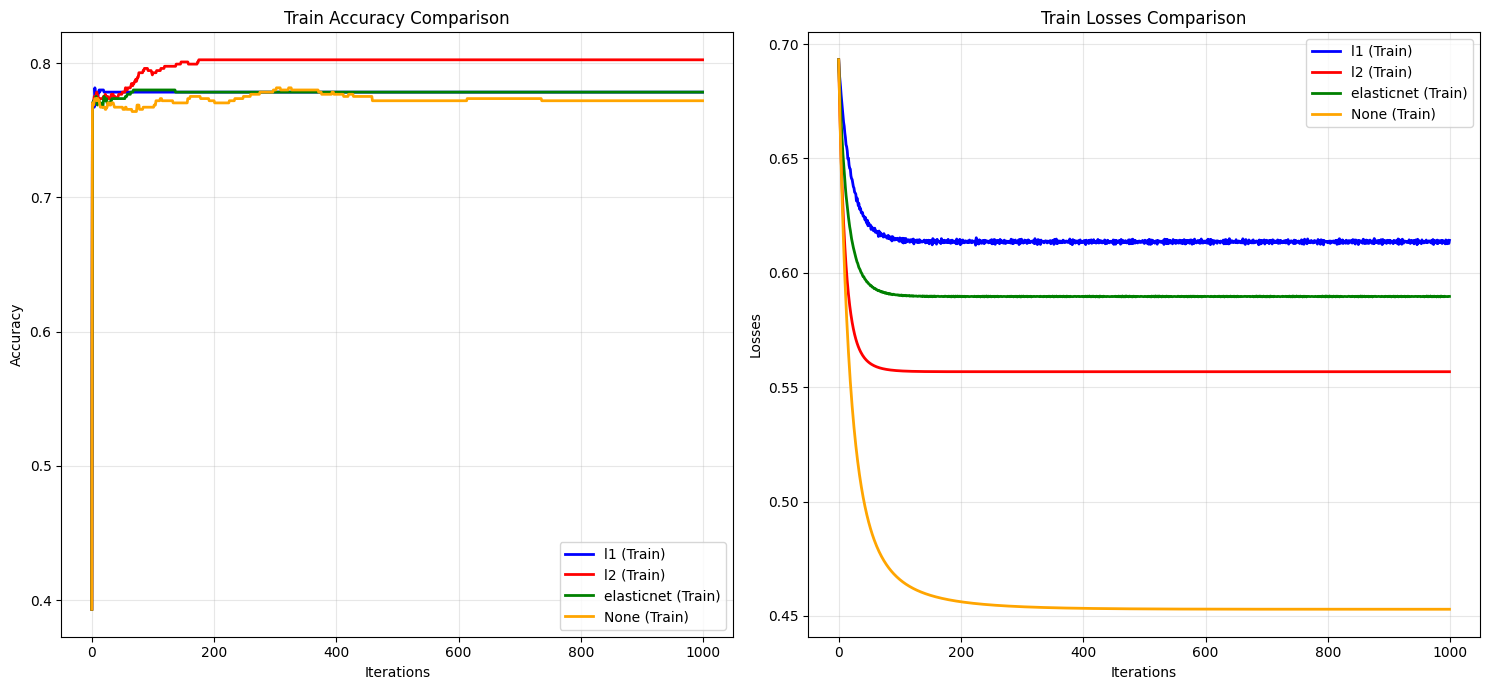

In [25]:
target_column = 'Survived'
X_cleaned = titanic.drop(target_column, axis=1).values.astype(np.float32)
y_cleaned = titanic[target_column].values.astype(np.float32)

separator = DataSeparator(test_size=0.15, val_size=0.15, shuffle=True, seed=42)
data_splits = separator.separate(X_cleaned, y_cleaned)

scaler = StandardScaler()
scaler.fit(data_splits.X_train)

data_splits.X_train = scaler.transform(data_splits.X_train)
data_splits.X_val = scaler.transform(data_splits.X_val)
data_splits.X_test = scaler.transform(data_splits.X_test)

models = [LogisticRegression(learning_rate=0.1, n_iterations=1000, verbose=True, regularization='l1', alpha=0.1),
          LogisticRegression(learning_rate=0.1, n_iterations=1000, verbose=True, regularization='l2', alpha=0.1),
          LogisticRegression(learning_rate=0.1, n_iterations=1000, verbose=True, regularization='elasticnet', alpha=0.1, l1_ratio=0.5),
          LogisticRegression(learning_rate=0.1, n_iterations=1000, verbose=True, regularization=None)]

for model in models:
  print(f"\nTraining {model.regularization} model")
  model.fit(data_splits.X_train, data_splits.y_train, data_splits.X_val, data_splits.y_val)

  predictions = model.predict(data_splits.X_test)

  # model.plot_metrics()

  print("Размеры выборок:")
  print(f"Train: {data_splits.X_train.shape[0]} samples")
  print(f"Validation: {data_splits.X_val.shape[0]} samples")
  print(f"Test: {data_splits.X_test.shape[0]} samples")
  print(f"Features: {data_splits.X_train.shape[1]} features")
  print(f"Accuracy на тестовой выборке: {model.score(data_splits.X_test, data_splits.y_test)}")
  print(f"F1 на тестовой выборке: {f1_score(data_splits.y_test.cpu(), predictions.cpu())}")
  print(f"Accuracy на обучающей выборке: {model.score(data_splits.X_train, data_splits.y_train)}")
  print(f"F1 на обучающей выборке: {f1_score(data_splits.y_train.cpu(), model.predict(data_splits.X_train).cpu())}")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
for i in range (len(models)):
  model = models[i]
  if model.history is not None:
    color = colors[i % len(colors)]
    axes[0].plot(model.history.accuracies,
                    label=f'{model.regularization} (Train)',
                    color=color,
                    linewidth=2)
    axes[1].plot(model.history.losses,
                    label=f'{model.regularization} (Train)',
                    color=color,
                    linewidth=2)
axes[0].set_title('Train Accuracy Comparison')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Train Losses Comparison')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Losses')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Калифорникейшн

In [4]:
import pandas as pd

californication = pd.read_csv('California_Houses.csv')
californication = californication.drop(['Tot_Bedrooms', 'Population', 'Households', 'Distance_to_SanDiego',
                                        'Distance_to_SanFrancisco', 'Distance_to_SanJose', 'Longitude'], axis=1)

californication

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Latitude,Distance_to_coast,Distance_to_LA
0,452600.0,8.3252,41,880,37.88,9263.040773,556529.158342
1,358500.0,8.3014,21,7099,37.86,10225.733072,554279.850069
2,352100.0,7.2574,52,1467,37.85,8259.085109,554610.717069
3,341300.0,5.6431,52,1274,37.85,7768.086571,555194.266086
4,342200.0,3.8462,52,1627,37.85,7768.086571,555194.266086
...,...,...,...,...,...,...,...
20635,78100.0,1.5603,25,1665,39.48,162031.481121,654530.186299
20636,77100.0,2.5568,18,697,39.49,160445.433537,659747.068444
20637,92300.0,1.7000,17,2254,39.43,153754.341182,654042.214020
20638,84700.0,1.8672,18,1860,39.43,152005.022239,657698.007703


In [5]:
@dataclass
class TrainingHistory:
    losses: list[float]
    train_loss_history: list[float]
    val_loss_history: list[float]
    train_mae_history: list[float]
    val_mae_history: list[float]
    train_rmse_history: list[float]
    val_rmse_history: list[float]
    weights_norm: list[float]

class LinearRegression:
    def __init__(self, learning_rate: float = 0.01, n_iterations: int = 10000, regularization: str = None,
                 tolerance: float = 1e-6, fit_intercept: bool = True, verbose: bool = False, alpha: float = 0.01, l1_ratio: float = 0.5):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance
        self.fit_intercept = fit_intercept
        self.verbose = verbose

        self.weights = None
        self.bias = 0.0 if fit_intercept else None
        self.is_fitted = False
        self.history = None

        self.regularization = regularization
        self.alpha = alpha
        self.l1_ratio = l1_ratio

    def compute_loss(self, y_true: torch.Tensor, y_pred: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
      base_loss = torch.mean((y_true - y_pred) ** 2)

      reg = 0
      if self.regularization == 'l1':
            reg = self.alpha * torch.sum(torch.abs(weights))
      elif self.regularization == 'l2':
            reg = self.alpha * torch.sum(weights ** 2)
      elif self.regularization == 'elasticnet':
            l1_reg = self.alpha * self.l1_ratio * torch.sum(torch.abs(weights))
            l2_reg = self.alpha * (1 - self.l1_ratio) * torch.sum(weights ** 2)
            reg = l1_reg + l2_reg

      return base_loss + reg

    def compute_mae(self, y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
      return torch.mean(torch.abs(y_true - y_pred))

    def compute_rmse(self, y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
      return torch.sqrt(self.compute_loss(y_true, y_pred, self.weights))

    def compute_gradients(self, X: torch.Tensor, error: torch.Tensor, weights: torch.Tensor) -> tuple:
        n_samples = X.shape[0]
        dw = (1 / n_samples) * torch.matmul(X.T, error)

        if self.regularization == 'l1':
            dw += self.alpha * torch.sign(weights)
        elif self.regularization == 'l2':
            dw += 2 * self.alpha * weights
        elif self.regularization == 'elasticnet':
            l1_grad = self.alpha * self.l1_ratio * torch.sign(weights)
            l2_grad = 2 * self.alpha * (1 - self.l1_ratio) * weights
            dw += l1_grad + l2_grad

        db = (1 / n_samples) * torch.sum(error) if self.fit_intercept else 0

        return dw, db

    def gradient_descent(self, X: torch.Tensor, y: torch.Tensor, X_val: torch.Tensor = None, y_val: torch.Tensor = None):
        n_samples, n_features = X.shape
        self.weights = torch.zeros(n_features, device=device)
        if self.fit_intercept:
            self.bias = torch.tensor(0.0, device=device)

        losses = []
        train_loss_history = []
        val_loss_history = []
        train_mae_history = []
        val_mae_history = []
        train_rmse_history = []
        val_rmse_history = []
        weights_norm = []

        for iteration in range(self.n_iterations):
            y_pred = torch.matmul(X, self.weights)
            if self.fit_intercept:
                y_pred += self.bias

            train_loss = self.compute_loss(y, y_pred, self.weights)
            train_mae = self.compute_mae(y, y_pred)
            train_rmse = self.compute_rmse(y, y_pred)

            train_loss_history.append(train_loss.item())
            train_mae_history.append(train_mae.item())
            train_rmse_history.append(train_rmse.item())
            losses.append(train_loss.item())
            weights_norm.append(torch.norm(self.weights).item())

            val_loss = val_mae = val_rmse = None
            if X_val is not None and y_val is not None:
                y_val_pred = torch.matmul(X_val, self.weights)
                if self.fit_intercept:
                    y_val_pred += self.bias

                val_loss = self.compute_loss(y_val, y_val_pred, self.weights)
                val_mae = self.compute_mae(y_val, y_val_pred)
                val_rmse = self.compute_rmse(y_val, y_val_pred)

                val_loss_history.append(val_loss.item())
                val_mae_history.append(val_mae.item())
                val_rmse_history.append(val_rmse.item())

            error = y_pred - y
            dw, db = self.compute_gradients(X, error, self.weights)

            self.weights -= self.learning_rate * dw

            if self.fit_intercept:
                self.bias -= self.learning_rate * db

            # if iteration > 0 and abs(losses[-2] - losses[-1]) < self.tolerance:
            #     if self.verbose:
            #         print(f"Converged at iteration {iteration}")
            #     break

            if self.verbose and iteration % 500 == 0:
                msg = f"Iteration {iteration}, Train Loss: {train_loss:.6f}"
                if val_loss is not None and val_mae is not None and val_rmse is not None:
                    msg += f", Val Loss: {val_loss:.6f}, MAE: {val_mae:.6f}, RMSE: {val_rmse:.6f}"
                print(msg)

        self.history = TrainingHistory(
            losses=losses,
            train_loss_history=train_loss_history,
            val_loss_history=val_loss_history,
            train_mae_history=train_mae_history,
            val_mae_history=val_mae_history,
            train_rmse_history=train_rmse_history,
            val_rmse_history=val_rmse_history,
            weights_norm=weights_norm
        )

    def fit(self, X: torch.Tensor, y: torch.Tensor, X_val: torch.Tensor = None, y_val: torch.Tensor = None):
        self.gradient_descent(X, y, X_val, y_val)
        self.is_fitted = True

    def predict(self, X: torch.Tensor) -> torch.Tensor:
        if not self.is_fitted:
            return X

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        y_pred = torch.matmul(X, self.weights)
        if self.fit_intercept:
            y_pred += self.bias

        return y_pred

    def score(self, X: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        y_pred = self.predict(X)
        ss_res = torch.sum((y - y_pred) ** 2)
        ss_tot = torch.sum((y - torch.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

    def plot_metrics(self):
      fig, axes = plt.subplots(3, figsize=(18, 5))

    # MSE
      axes[0].plot(self.history.train_loss_history, label='Train')
      if self.history.val_loss_history:
          axes[0].plot(self.history.val_loss_history, label='Validation')
      axes[0].set_title('MSE during Training')
      axes[0].set_yscale('log')
      axes[0].legend()
      axes[0].grid(True)

    # MAE
      axes[1].plot(self.history.train_mae_history, label='Train')
      if self.history.val_mae_history:
          axes[1].plot(self.history.val_mae_history, label='Validation')
      axes[1].set_title('MAE during Training')
      axes[1].set_yscale('log')
      axes[1].legend()
      axes[1].grid(True)

    # RMSE
      axes[2].plot(self.history.train_rmse_history, label='Train')
      if self.history.val_rmse_history:
          axes[2].plot(self.history.val_rmse_history, label='Validation')
      axes[2].set_title('RMSE during Training')
      axes[2].set_yscale('log')
      axes[2].legend()
      axes[2].grid(True)

      plt.tight_layout()
      plt.show()


Training l1 model
Iteration 0, Train Loss: 55980097536.000000, Val Loss: 55991472128.000000, MAE: 207391.921875, RMSE: 236625.171875
Iteration 500, Train Loss: 5497142784.000000, Val Loss: 5336499200.000000, MAE: 54371.238281, RMSE: 73051.343750
Iteration 1000, Train Loss: 5496679936.000000, Val Loss: 5337183232.000000, MAE: 54376.878906, RMSE: 73056.031250
Iteration 1500, Train Loss: 5496677376.000000, Val Loss: 5337271808.000000, MAE: 54377.511719, RMSE: 73056.632812
Iteration 2000, Train Loss: 5496676352.000000, Val Loss: 5337278976.000000, MAE: 54377.558594, RMSE: 73056.679688
Iteration 2500, Train Loss: 5496677376.000000, Val Loss: 5337278976.000000, MAE: 54377.562500, RMSE: 73056.679688
Iteration 3000, Train Loss: 5496677376.000000, Val Loss: 5337278976.000000, MAE: 54377.562500, RMSE: 73056.679688
Iteration 3500, Train Loss: 5496677376.000000, Val Loss: 5337278976.000000, MAE: 54377.562500, RMSE: 73056.679688
Iteration 4000, Train Loss: 5496677376.000000, Val Loss: 5337278976.0

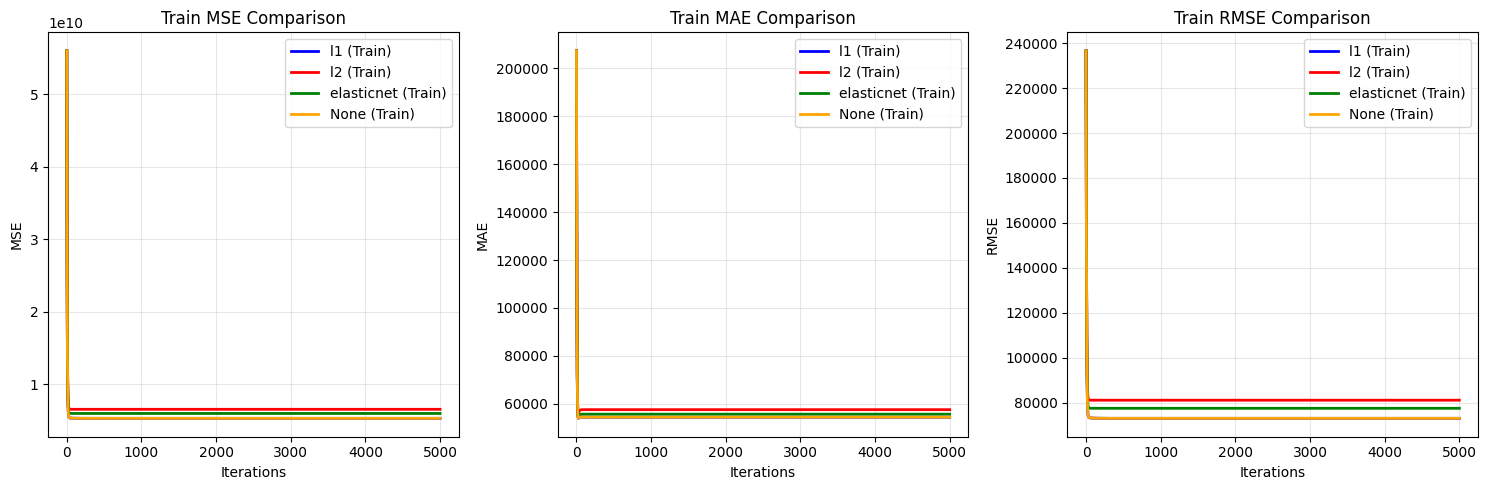

In [10]:
import matplotlib.pyplot as plt

target_column = 'Median_House_Value'
X_cleaned = californication.drop(target_column, axis=1).values.astype(np.float32)
y_cleaned = californication[target_column].values.astype(np.float32)

separator = DataSeparator(test_size=0.15, val_size=0.15, shuffle=True, seed=42)
data_splits = separator.separate(X_cleaned, y_cleaned)

scaler = StandardScaler()
scaler.fit(data_splits.X_train)

data_splits.X_train = scaler.transform(data_splits.X_train)
data_splits.X_val = scaler.transform(data_splits.X_val)
data_splits.X_test = scaler.transform(data_splits.X_test)

models = [LinearRegression(learning_rate=0.1, n_iterations=5000, verbose=True, regularization='l1', alpha=0.2),
          LinearRegression(learning_rate=0.1, n_iterations=5000, verbose=True, regularization='l2', alpha=0.2),
          LinearRegression(learning_rate=0.1, n_iterations=5000, verbose=True, regularization='elasticnet', alpha=0.2, l1_ratio=0.5),
          LinearRegression(learning_rate=0.1, n_iterations=5000, verbose=True, regularization=None)]

for model in models:
  print(f"\nTraining {model.regularization} model")
  model.fit(data_splits.X_train, data_splits.y_train, data_splits.X_val, data_splits.y_val)

  predictions = model.predict(data_splits.X_test)

  r2_test = model.score(data_splits.X_test, data_splits.y_test)
  r2_train = model.score(data_splits.X_train, data_splits.y_train)

  # model.plot_metrics()

  print("\nРазмеры выборок:")
  print(f"Train: {data_splits.X_train.shape[0]} samples")
  print(f"Test: {data_splits.X_test.shape[0]} samples")
  print(f"Val: {data_splits.X_val.shape[0]} samples")
  print(f"R^2 на тестовой выборке: {r2_test:.4f}")
  print(f"R^2 на обучающие выборке: {r2_train:.4f}")
  print(f"Validation: {data_splits.X_val.shape[0]} samples")
  print(f"Test: {data_splits.X_test.shape[0]} samples")
  print(f"Features: {data_splits.X_train.shape[1]} features")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
for i in range (len(models)):
  model = models[i]
  if model.history is not None:
    color = colors[i % len(colors)]
    axes[0].plot(model.history.val_loss_history,
                    label=f'{model.regularization} (Train)',
                    color=color,
                    linewidth=2)
    axes[1].plot(model.history.val_mae_history,
                    label=f'{model.regularization} (Train)',
                    color=color,
                    linewidth=2)
    axes[2].plot(model.history.val_rmse_history,
                    label=f'{model.regularization} (Train)',
                    color=color,
                    linewidth=2)

axes[0].set_title('Train MSE Comparison')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Train MAE Comparison')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_title('Train RMSE Comparison')
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel('RMSE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 2 🤯

1. пишем класс модели KNN
2. в классе должны быть методы
```
def __init__(...):
# some code
def predict(...):
# some code
def fit(...):
# some code
```
и все остальное, что вам необходимо

По параметру берем расстояние

3. берем датасеты (классификация [тык](https://www.kaggle.com/datasets/zalando-research/fashionmnist), регрессия [тык](https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset/data))
4. обучаем модель
5. выводим метрики качества (ошибки, точность предсказаний, etc.)

In [33]:
import numpy as np
import torch

class KNN:
  def __init__(self, k: int = 5, distance: str = None, task: str = None, batch_size: int = 500, device=None) -> None:
    self.k = k
    self.distance = distance
    self.task = task
    self.is_fitted = False
    self.X_train: torch.Tensor = None
    self.y_train: torch.Tensor = None
    self.batch_size = batch_size
    self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

  def _compute_distance(self, X: torch.Tensor) -> torch.Tensor:
    X = X.to(self.device)
    X_train = self.X_train

    if self.distance == "euclidean":
        X2 = torch.sum(X**2, dim=1, keepdims=True)
        T2 = torch.sum(self.X_train**2, dim=1).unsqueeze(0)
        D2 = X2 + T2 - 2 * X @ self.X_train.T
        dists = torch.sqrt(torch.clamp(D2, min=0.0))
    elif self.distance == "manhattan":
        dists = torch.cdist(X, X_train, p=1)
    elif self.distance == "cos":
        dists = 1 - torch.mm(
                torch.nn.functional.normalize(X, dim=1),
                torch.nn.functional.normalize(X_train, dim=1).T
            )
    else:
      raise ValueError(f"Я не знаю че это такое: {self.distance}")

    return dists

  def predict(self, X: torch.Tensor) -> torch.Tensor:
    if self.task is None:
      raise ValueError("Выберите задачу :( я откуда знаю, что вам нужно?")
    if self.distance is None:
      raise ValueError("Выберите какое расстояние считать :(")
    if self.is_fitted:
      print("Окееей летс гоу")
      print("---------------------------------------------------------------------------------------------")

      y_pred = []

      X = X.to(self.device)
      n_samples = X.shape[0]
      for start in range (0, n_samples, self.batch_size):
        end = min(start + self.batch_size, n_samples)
        X_batch = X[start:end]

        print(f"Считаю расстояния для батча {start}-{end}...")
        dists = self._compute_distance(X_batch)
        print("Посчитал!")
        nearest = torch.argsort(dists, axis=1)[:, :self.k]
        y_neighbors = self.y_train[nearest]

        if self.task == "classification":
            preds = torch.mode(y_neighbors, dim=1).values
        elif self.task == "regression":
            preds = torch.mean(y_neighbors.float(), dim=1)
        else:
            raise ValueError(f"Я не понимаю что вы от меня хотите: {self.task}")

        y_pred.append(preds.detach().cpu())

      y_pred = torch.cat(y_pred)
      print("---------------------------------------------------------------------------------------------")
      print("Готово!\n")
      return y_pred

    else:
      raise ValueError("Модель еще не стройная💅")

  def fit(self, X: torch.Tensor, y: torch.Tensor) -> None:
    self.X_train = X.to(self.device)
    self.y_train = y.to(self.device)
    self.is_fitted = True

### Фэшн классификейшн

In [30]:
import pandas as pd

fashion_train = pd.read_csv('fashion-mnist_train.csv')
fashion_test = pd.read_csv('fashion-mnist_test.csv')

In [ ]:
fashion_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
from sklearn.metrics import accuracy_score, classification_report

target_column = "label"
X_train = torch.tensor(fashion_train.drop(target_column, axis=1).values, dtype=torch.float32)
y_train = torch.tensor(fashion_train[target_column].values)
X_test = torch.tensor(fashion_test.drop(target_column, axis=1).values, dtype=torch.float32)
y_test = torch.tensor(fashion_test[target_column].values, dtype=torch.long)

model = KNN(k = 15, distance="manhattan", task="classification", batch_size = 500, device=device)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Аккураси:", accuracy_score(y_test.cpu().numpy(), y_pred.cpu().numpy()))
print(classification_report(y_test.cpu().numpy(), y_pred.cpu().numpy()))

Окееей летс гоу
---------------------------------------------------------------------------------------------
Считаю расстояния для батча 0-500...
Посчитал!
Считаю расстояния для батча 500-1000...
Посчитал!
Считаю расстояния для батча 1000-1500...
Посчитал!
Считаю расстояния для батча 1500-2000...
Посчитал!
Считаю расстояния для батча 2000-2500...
Посчитал!
Считаю расстояния для батча 2500-3000...
Посчитал!
Считаю расстояния для батча 3000-3500...
Посчитал!
Считаю расстояния для батча 3500-4000...
Посчитал!
Считаю расстояния для батча 4000-4500...
Посчитал!
Считаю расстояния для батча 4500-5000...
Посчитал!
Считаю расстояния для батча 5000-5500...
Посчитал!
Считаю расстояния для батча 5500-6000...
Посчитал!
Считаю расстояния для батча 6000-6500...
Посчитал!
Считаю расстояния для батча 6500-7000...
Посчитал!
Считаю расстояния для батча 7000-7500...
Посчитал!
Считаю расстояния для батча 7500-8000...
Посчитал!
Считаю расстояния для батча 8000-8500...
Посчитал!
Считаю расстояния для батча 

### Страховочная регрессия (не придумала шутку)

In [43]:
import pandas as pd

insurance = pd.read_csv('insurance.csv')
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [44]:
insurance.sex = insurance.sex.map({'female':0, 'male':1})
insurance.smoker = insurance.smoker.map({'no':0, 'yes':1})
insurance = pd.get_dummies(insurance, columns=["region"], drop_first=False)
insurance

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,False,True,False,False
1334,18,0,31.920,0,0,2205.98080,True,False,False,False
1335,18,0,36.850,0,0,1629.83350,False,False,True,False
1336,21,0,25.800,0,0,2007.94500,False,False,False,True


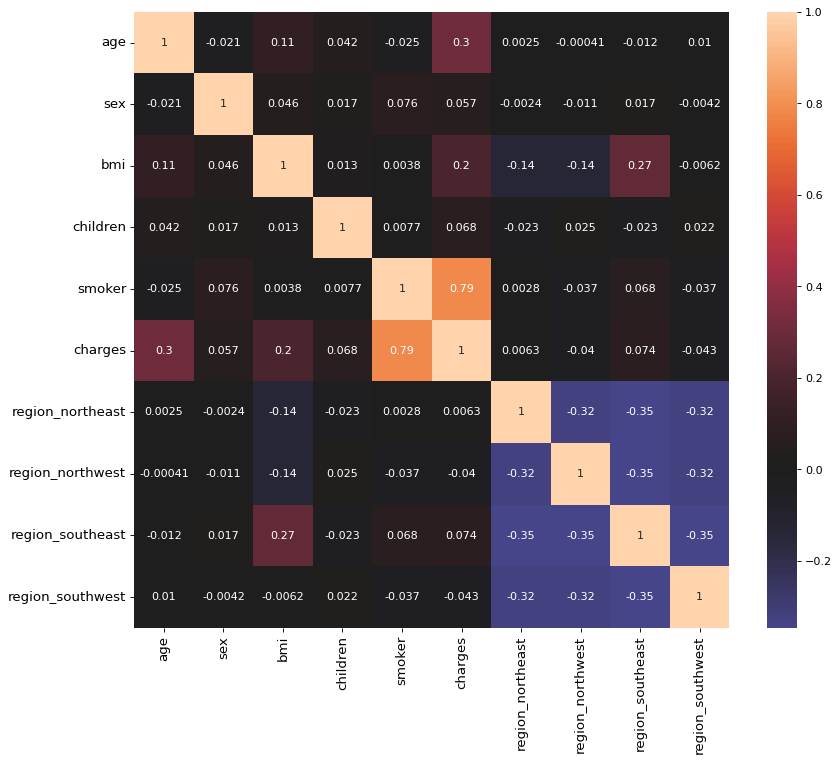

In [45]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10), dpi= 80)
sns.heatmap(insurance.corr(), xticklabels=insurance.corr().columns, yticklabels=insurance.corr().columns, center=0, annot=True,)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [46]:
insurance = insurance.drop("region_northeast", axis=1)

insurance.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
charges,0
region_northwest,0
region_southeast,0
region_southwest,0


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target_column = 'charges'
X_cleaned = insurance.drop(target_column, axis=1).values.astype(np.float32)
y_cleaned = insurance[target_column].values.astype(np.float32)

separator = DataSeparator(test_size=0.15, val_size=0.15, shuffle=True, seed=42)
data_splits = separator.separate(X_cleaned, y_cleaned)

scaler = StandardScaler()
scaler.fit(data_splits.X_train)

data_splits.X_train = scaler.transform(data_splits.X_train)
data_splits.X_val = scaler.transform(data_splits.X_val)
data_splits.X_test = scaler.transform(data_splits.X_test)

model = KNN(k = 13, distance="cos", task="regression", batch_size=50, device=device)
model.fit(data_splits.X_train, data_splits.y_train)

y_pred = model.predict(data_splits.X_test)

mae = mean_absolute_error(data_splits.y_test.cpu().numpy(), y_pred.cpu().numpy())
mse = mean_squared_error(data_splits.y_test.cpu().numpy(), y_pred.cpu().numpy())
rmse = np.sqrt(mse)
r2 = r2_score(data_splits.y_test.cpu().numpy(), y_pred.cpu().numpy())

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

Окееей летс гоу
---------------------------------------------------------------------------------------------
Считаю расстояния для батча 0-50...
Посчитал!
Считаю расстояния для батча 50-100...
Посчитал!
Считаю расстояния для батча 100-150...
Посчитал!
Считаю расстояния для батча 150-200...
Посчитал!
---------------------------------------------------------------------------------------------
Готово!

MAE: 3780.461
MSE: 34908944.000
RMSE: 5908.379
R²: 0.747
